# UK Road Safety — Exploratory Data Analysis

## Project Overview

This exploratory data analysis examines the UK Road Safety dataset to identify patterns in traffic accidents and explore factors that may be associated with accident severity. The analysis will focus on data quality, accident characteristics, road and environmental conditions, and relationships that may be useful for later modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os

os.listdir("../data")

['.DS_Store', 'archive']

In [3]:
os.listdir("../data/archive")

['Accident_Information.csv', 'Vehicle_Information.csv']

## Load the Data

The UK Road Safety data is provided in two datasets: accident information and vehicle information. I will first examine the accident-level dataset to understand its structure, quality, and key variables before exploring the vehicle-level data.

In [4]:
accidents = pd.read_csv(
    "../data/archive/Accident_Information.csv",
    low_memory=False
)

accidents.head()

,Accident_Index,1st_Road_Class,1st_Road_Number,2nd_Road_Class,2nd_Road_Number,Accident_Severity,Carriageway_Hazards,Date,Day_of_Week,Did_Police_Officer_Attend_Scene_of_Accident,...,Police_Force,Road_Surface_Conditions,Road_Type,Special_Conditions_at_Site,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Year,InScotland
0,200501BS00001,A,3218.0,NaN,0.0,Serious,NaN,2005-01-04,Tuesday,1.0,...,Metropolitan Police,Wet or damp,Single carriageway,NaN,30.0,17:42,Urban,Raining no high winds,2005,No
1,200501BS00002,B,450.0,C,0.0,Slight,NaN,2005-01-05,Wednesday,1.0,...,Metropolitan Police,Dry,Dual carriageway,NaN,30.0,17:36,Urban,Fine no high winds,2005,No
2,200501BS00003,C,0.0,NaN,0.0,Slight,NaN,2005-01-06,Thursday,1.0,...,Metropolitan Police,Dry,Single carriageway,NaN,30.0,00:15,Urban,Fine no high winds,2005,No
3,200501BS00004,A,3220.0,NaN,0.0,Slight,NaN,2005-01-07,Friday,1.0,...,Metropolitan Police,Dry,Single carriageway,NaN,30.0,10:35,Urban,Fine no high winds,2005,No
4,200501BS00005,Unclassified,0.0,NaN,0.0,Slight,NaN,2005-01-10,Monday,1.0,...,Metropolitan Police,Wet or damp,Single carriageway,NaN,30.0,21:13,Urban,Fine no high winds,2005,No


## Dataset Overview

Before exploring individual accident patterns, I first examined the size, column types, and overall structure of the accident dataset. This helps identify potential data quality issues and determines which variables may be useful for further analysis.

In [5]:
accidents.shape

(2047256, 34)

In [6]:
accidents.columns.tolist()

['Accident_Index',
 '1st_Road_Class',
 '1st_Road_Number',
 '2nd_Road_Class',
 '2nd_Road_Number',
 'Accident_Severity',
 'Carriageway_Hazards',
 'Date',
 'Day_of_Week',
 'Did_Police_Officer_Attend_Scene_of_Accident',
 'Junction_Control',
 'Junction_Detail',
 'Latitude',
 'Light_Conditions',
 'Local_Authority_(District)',
 'Local_Authority_(Highway)',
 'Location_Easting_OSGR',
 'Location_Northing_OSGR',
 'Longitude',
 'LSOA_of_Accident_Location',
 'Number_of_Casualties',
 'Number_of_Vehicles',
 'Pedestrian_Crossing-Human_Control',
 'Pedestrian_Crossing-Physical_Facilities',
 'Police_Force',
 'Road_Surface_Conditions',
 'Road_Type',
 'Special_Conditions_at_Site',
 'Speed_limit',
 'Time',
 'Urban_or_Rural_Area',
 'Weather_Conditions',
 'Year',
 'InScotland']

In [7]:
accidents.info()

<class 'pandas.DataFrame'>
RangeIndex: 2047256 entries, 0 to 2047255
Data columns (total 34 columns):
 #   Column                                       Dtype  
---  ------                                       -----  
 0   Accident_Index                               str    
 1   1st_Road_Class                               str    
 2   1st_Road_Number                              float64
 3   2nd_Road_Class                               str    
 4   2nd_Road_Number                              float64
 5   Accident_Severity                            str    
 6   Carriageway_Hazards                          str    
 7   Date                                         str    
 8   Day_of_Week                                  str    
 9   Did_Police_Officer_Attend_Scene_of_Accident  float64
 10  Junction_Control                             str    
 11  Junction_Detail                              str    
 12  Latitude                                     float64
 13  Light_Conditions       

 ### Data Quality Check

I checked the dataset for missing values and duplicate records before beginning the visual analysis. Understanding where data is incomplete will help determine which variables may require cleaning or special handling during preprocessing.

In [8]:
missing_values = accidents.isnull().sum().sort_values(ascending=False)

missing_values

Carriageway_Hazards                            2007807
Special_Conditions_at_Site                     1995137
2nd_Road_Class                                  844272
LSOA_of_Accident_Location                       144953
2nd_Road_Number                                  17593
Pedestrian_Crossing-Physical_Facilities           3560
Pedestrian_Crossing-Human_Control                 2920
Did_Police_Officer_Attend_Scene_of_Accident        278
Longitude                                          175
Latitude                                           174
Location_Northing_OSGR                             164
Location_Easting_OSGR                              164
Time                                               156
InScotland                                          53
Speed_limit                                         37
1st_Road_Number                                      2
Local_Authority_(District)                           0
Local_Authority_(Highway)                            0
Year      

In [9]:
missing_percent = ( 
    accidents.isnull().mean() * 100
).sort_values(ascending=False)

missing_percent

# This will show us exactly what percentage of each column is missing.

Carriageway_Hazards                            98.073079
Special_Conditions_at_Site                     97.454202
2nd_Road_Class                                 41.239200
LSOA_of_Accident_Location                       7.080355
2nd_Road_Number                                 0.859345
Pedestrian_Crossing-Physical_Facilities         0.173891
Pedestrian_Crossing-Human_Control               0.142630
Did_Police_Officer_Attend_Scene_of_Accident     0.013579
Longitude                                       0.008548
Latitude                                        0.008499
Location_Northing_OSGR                          0.008011
Location_Easting_OSGR                           0.008011
Time                                            0.007620
InScotland                                      0.002589
Speed_limit                                     0.001807
1st_Road_Number                                 0.000098
Local_Authority_(District)                      0.000000
Local_Authority_(Highway)      

### Missing Value Observation

Most variables have little to no missing data. However, `Carriageway_Hazards` and `Special_Conditions_at_Site` are missing more than 97% of their values, while `2nd_Road_Class` is missing about 41%. These columns may require special consideration during preprocessing rather than simply removing rows with missing values.

In [10]:
accidents.duplicated().sum() 

# check duplicates

np.int64(0)

No fully duplicated records were found in the accident dataset.

### Missing Value Observation

Most variables have little to no missing data. However, `Carriageway_Hazards` and `Special_Conditions_at_Site` are missing more than 97% of their values, while `2nd_Road_Class` is missing about 41%. These columns may require special consideration during preprocessing rather than simply removing rows with missing values.

No fully duplicated records were found in the accident dataset.

## 1. Accident Severity Distribution

In [11]:
accidents["Accident_Severity"].value_counts()

Accident_Severity
Slight     1734548
Serious     286339
Fatal        26369
Name: count, dtype: int64

In [12]:
accidents["Accident_Severity"].value_counts(normalize=True) * 100

# This will tell us what percentage of accidents fall into each severity category.

Accident_Severity
Slight     84.725506
Serious    13.986478
Fatal       1.288017
Name: proportion, dtype: float64

### Accident Severity Distribution

Accident severity is noticeably imbalanced. About 84.7% of the recorded accidents were classified as slight, while approximately 14.0% were serious and only 1.3% were fatal. This imbalance will be important to consider later when building a classification model, since accuracy alone may not provide a complete picture of model performance.

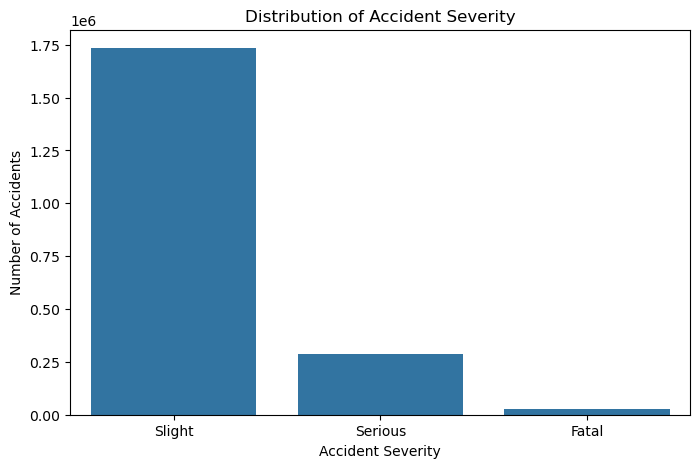

In [13]:
severity_order = ["Slight", "Serious", "Fatal"]

plt.figure(figsize=(8, 5))

sns.countplot(
    data=accidents,
    x="Accident_Severity",
    order=severity_order
)

plt.title("Distribution of Accident Severity")
plt.xlabel("Accident Severity")
plt.ylabel("Number of Accidents")
plt.show()

In [14]:
accidents["Day_of_Week"].value_counts()

Day_of_Week
Friday       335183
Wednesday    308580
Thursday     308240
Tuesday      306292
Monday       290482
Saturday     273152
Sunday       225327
Name: count, dtype: int64

### Day of the Week Observation

Accidents occurred most frequently on Friday, with 335,183 recorded accidents, while Sunday had the fewest with 225,327. Overall, accident counts were higher during the weekdays and decreased over the weekend. However, these counts show accident frequency only and do not necessarily mean that accidents are more likely to occur on a particular day, since traffic volume may also vary throughout the week.

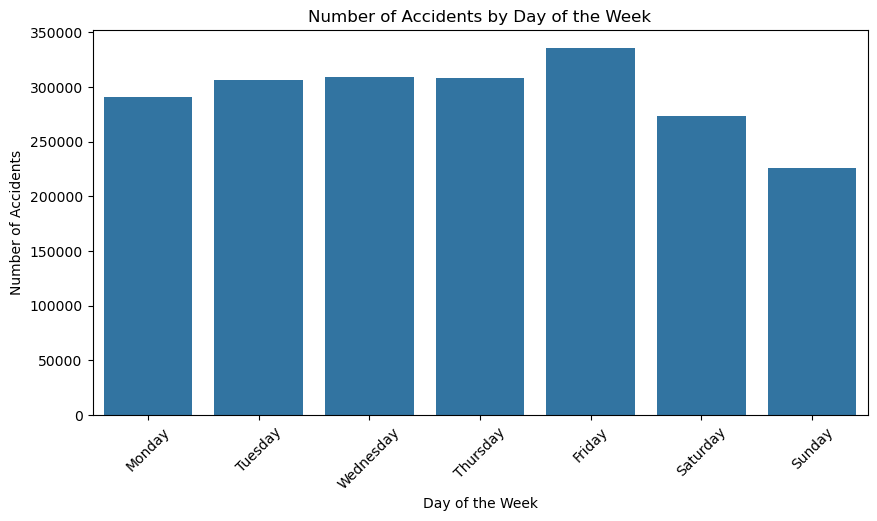

In [15]:
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

plt.figure(figsize=(10, 5))

sns.countplot(
    data=accidents,
    x="Day_of_Week",
    order=day_order
)

plt.title("Number of Accidents by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.show()

## 2. Speed Limit vs. Accident Severity

In [16]:
accidents["Speed_limit"].value_counts().sort_index()

Speed_limit
0.0           1
10.0         19
15.0         16
20.0      38399
30.0    1306174
40.0     168357
50.0      69479
60.0     317469
70.0     147305
Name: count, dtype: int64

In [17]:
common_speed_limits = [20, 30, 40, 50, 60, 70]

speed_severity = pd.crosstab(
    accidents.loc[
        accidents["Speed_limit"].isin(common_speed_limits),
        "Speed_limit"
    ],
    accidents.loc[
        accidents["Speed_limit"].isin(common_speed_limits),
        "Accident_Severity"
    ],
    normalize="index"
) * 100

speed_severity = speed_severity[
    ["Slight", "Serious", "Fatal"]
]

speed_severity.round(2)

Accident_Severity,Slight,Serious,Fatal
Speed_limit,,,
20.0,84.81,14.66,0.52
30.0,86.56,12.77,0.67
40.0,84.43,14.10,1.47
50.0,82.49,15.30,2.21
60.0,77.54,19.30,3.15
70.0,85.27,12.41,2.32


### Speed Limit and Accident Severity

Accident severity varied across speed limits. Roads with a 60 mph speed limit had the highest proportion of serious accidents (19.3%) and fatal accidents (3.15%). Fatal accidents also became more common from 30 mph through 60 mph, although the pattern did not continue at 70 mph. This suggests that speed limit may be related to accident severity, but other factors such as road type and location may also play a role.

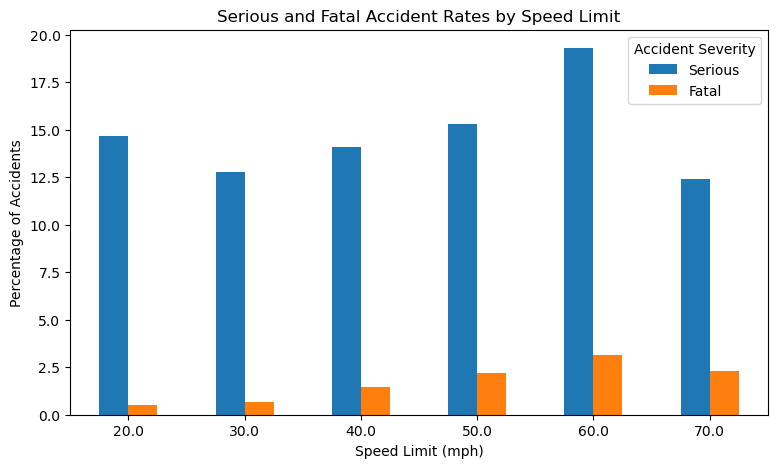

In [18]:
speed_severity[["Serious", "Fatal"]].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Serious and Fatal Accident Rates by Speed Limit")
plt.xlabel("Speed Limit (mph)")
plt.ylabel("Percentage of Accidents")
plt.xticks(rotation=0)
plt.legend(title="Accident Severity")
plt.show()

In [19]:
accidents["Weather_Conditions"].value_counts()

Weather_Conditions
Fine no high winds              1640095
Raining no high winds            239281
Other                             44083
Unknown                           42521
Raining + high winds              28343
Fine + high winds                 25816
Snowing no high winds             13387
Fog or mist                       11068
Snowing + high winds               2487
Data missing or out of range        175
Name: count, dtype: int64

In [20]:
weather_severity = pd.crosstab(
    accidents["Weather_Conditions"],
    accidents["Accident_Severity"],
    normalize="index"
) * 100

weather_severity = weather_severity[
    ["Slight", "Serious", "Fatal"]
]

weather_severity.round(2)

Accident_Severity,Slight,Serious,Fatal
Weather_Conditions,,,
Data missing or out of range,89.71,7.43,2.86
Fine + high winds,82.93,15.20,1.86
Fine no high winds,84.29,14.38,1.33
Fog or mist,83.01,14.84,2.15
Other,87.62,11.47,0.90
Raining + high winds,84.76,13.83,1.41
Raining no high winds,86.38,12.56,1.06
Snowing + high winds,87.54,11.86,0.60
Snowing no high winds,89.11,10.07,0.82


### Weather Conditions and Accident Severity

Weather conditions showed some differences in accident severity, although the relationship was not as strong as the pattern seen with speed limits. Fog or mist had a relatively high fatal accident rate of 2.15%, while fine weather with high winds had one of the highest serious accident rates at 15.2%. Overall, poor weather conditions did not consistently correspond with more severe accidents, suggesting that weather alone may not explain accident severity.

## 3. Light Conditions vs. Accident Severity

In [21]:
accidents["Light_Conditions"].value_counts()

Light_Conditions
Daylight                        1496121
Darkness - lights lit            404144
Darkness - no lighting           112644
Darkness - lighting unknown       24362
Darkness - lights unlit            9971
Data missing or out of range         14
Name: count, dtype: int64

In [22]:
light_severity = pd.crosstab(
    accidents["Light_Conditions"],
    accidents["Accident_Severity"],
    normalize="index"
) * 100

light_severity = light_severity[
    ["Slight", "Serious", "Fatal"]
]

light_severity.round(2)

Accident_Severity,Slight,Serious,Fatal
Light_Conditions,,,
Darkness - lighting unknown,85.38,13.35,1.27
Darkness - lights lit,83.44,15.22,1.35
Darkness - lights unlit,82.37,15.73,1.91
Darkness - no lighting,75.73,19.88,4.39
Data missing or out of range,92.86,0.00,7.14
Daylight,85.76,13.21,1.03


### Light Conditions and Accident Severity

Accident severity was noticeably higher under darker road conditions. In daylight, 13.21% of accidents were serious and 1.03% were fatal. In comparison, accidents occurring in darkness with no lighting had the highest proportion of serious accidents at 19.88% and fatal accidents at 4.39%. This suggests that lighting conditions may be an important factor to consider when examining accident severity.

## 4. Urban vs. Rural Accident Severity

In [23]:
accidents["Urban_or_Rural_Area"].value_counts()

Urban_or_Rural_Area
Urban          1322339
Rural           724757
Unallocated        160
Name: count, dtype: int64

In [24]:
urban_rural_severity = pd.crosstab(
    accidents["Urban_or_Rural_Area"],
    accidents["Accident_Severity"],
    normalize="index"
) * 100

urban_rural_severity = urban_rural_severity.loc[
    ["Urban", "Rural"],
    ["Slight", "Serious", "Fatal"]
]

urban_rural_severity.round(2)

Accident_Severity,Slight,Serious,Fatal
Urban_or_Rural_Area,,,
Urban,86.69,12.61,0.71
Rural,81.15,16.50,2.35


### Urban vs. Rural Accident Severity

Accidents in rural areas were more likely to result in severe outcomes than accidents in urban areas. About 16.5% of rural accidents were serious compared with 12.61% in urban areas. Fatal accidents accounted for 2.35% of rural accidents, compared with only 0.71% of urban accidents. This suggests that location type may be an important factor when examining accident severity.

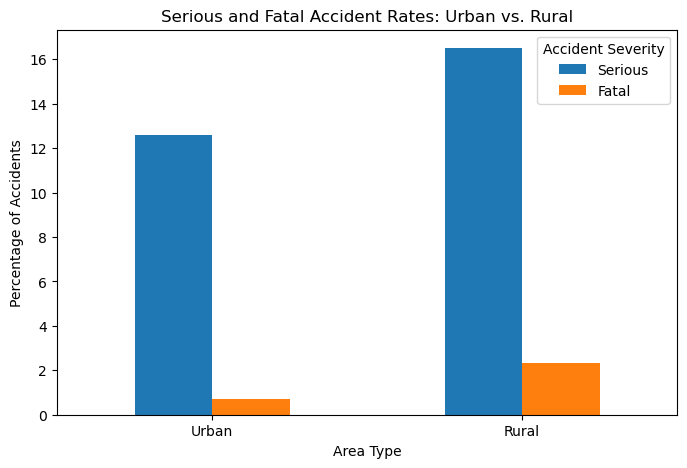

In [25]:
urban_rural_severity[["Serious", "Fatal"]].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Serious and Fatal Accident Rates: Urban vs. Rural")
plt.xlabel("Area Type")
plt.ylabel("Percentage of Accidents")
plt.xticks(rotation=0)
plt.legend(title="Accident Severity")
plt.show()

## Key EDA Findings

The exploratory analysis highlighted four findings that may be especially useful for understanding and modeling accident severity:

1. **Accident severity is highly imbalanced.** Most accidents were classified as slight (84.73%), while serious accidents represented 13.99% and fatal accidents only 1.29%.

2. **Accident severity varied by speed limit.** Roads with a 60 mph speed limit had the highest proportion of serious accidents (19.30%) and fatal accidents (3.15%) among the common speed limits examined.

3. **Poor lighting was associated with more severe outcomes.** Accidents occurring in darkness with no lighting had the highest serious (19.88%) and fatal (4.39%) accident percentages among the lighting conditions examined.

4. **Rural accidents were more severe than urban accidents.** Serious accidents accounted for 16.50% of rural accidents compared with 12.61% in urban areas, while fatal accidents represented 2.35% of rural accidents compared with 0.71% in urban areas.

These findings suggest that speed limit, lighting conditions, and urban/rural location may be useful variables to consider when the team moves into preprocessing and supervised modeling.